# UCI HAR — Preprocessing Pipeline
Human Activity Recognition Using Smartphones (UCI id 240). This notebook produces **two model-ready views** of the data:

| View | Shape | For |
|---|---|---|
| **Tabular** — 561 engineered features | `(N, 561)` | Logistic Regression, SVM, Random Forest, XGBoost, KNN, MLP |
| **Sequence** — raw inertial windows | `(N, 128, 9)` | 1D-CNN, LSTM/GRU, CNN-LSTM, Transformers |

Pipeline: **load → clean → encode → subject-wise split → normalize → augment (train only) → save**.

Two rules this notebook enforces, because they're where HAR results most often go wrong:
1. **Split by subject, not by row.** Windows overlap 50%, so a random row split leaks near-identical windows between train and test.
2. **Fit scalers on train only**, and augment train only.

Runtime: CPU is fine for this notebook (Runtime → Change runtime type → GPU only matters later for training).

## 1. Setup and download

In [1]:
import os, zipfile, urllib.request, json
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

DATA_DIR = "/content/har"          # change if not on Colab
OUT_DIR  = "/content/har_processed"
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)

URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ROOT = os.path.join(DATA_DIR, "UCI HAR Dataset")

if not os.path.isdir(ROOT):
    outer = os.path.join(DATA_DIR, "har_outer.zip")
    urllib.request.urlretrieve(URL, outer)
    with zipfile.ZipFile(outer) as z: z.extractall(DATA_DIR)
    # The UCI download is a zip that contains another zip
    inner = os.path.join(DATA_DIR, "UCI HAR Dataset.zip")
    if os.path.exists(inner):
        with zipfile.ZipFile(inner) as z: z.extractall(DATA_DIR)
print(os.listdir(ROOT))

['activity_labels.txt', 'README.txt', 'features.txt', 'train', 'test', '.DS_Store', 'features_info.txt']


## 2. Load both views
The engineered features and the raw inertial signals are row-aligned, so row *i* in `X_train.txt` is the same window as row *i* in each `Inertial Signals` file.

In [2]:
def read_txt(path):
    return pd.read_csv(path, sep=r"\s+", header=None)

features = read_txt(f"{ROOT}/features.txt")[1].tolist()
activity_map = read_txt(f"{ROOT}/activity_labels.txt").set_index(0)[1].to_dict()

SIGNALS = ["body_acc_x","body_acc_y","body_acc_z",
           "body_gyro_x","body_gyro_y","body_gyro_z",
           "total_acc_x","total_acc_y","total_acc_z"]

def load_split(split):
    X  = read_txt(f"{ROOT}/{split}/X_{split}.txt")
    y  = read_txt(f"{ROOT}/{split}/y_{split}.txt")[0].map(activity_map)
    sub = read_txt(f"{ROOT}/{split}/subject_{split}.txt")[0]
    seq = np.stack([read_txt(f"{ROOT}/{split}/Inertial Signals/{s}_{split}.txt").values
                    for s in SIGNALS], axis=-1)            # (N, 128, 9)
    return X, y, sub, seq

Xtr_df, ytr, subtr, Seq_tr = load_split("train")
Xte_df, yte, subte, Seq_te = load_split("test")

# Pool everything; we re-split by subject ourselves in step 5
X_df   = pd.concat([Xtr_df, Xte_df], ignore_index=True)
y_str  = pd.concat([ytr, yte], ignore_index=True)
subj   = pd.concat([subtr, subte], ignore_index=True).values
SEQ    = np.concatenate([Seq_tr, Seq_te]).astype(np.float32)
orig_split = np.array(["train"]*len(ytr) + ["test"]*len(yte))

print("Tabular:", X_df.shape, "| Sequence:", SEQ.shape, "| Subjects:", len(np.unique(subj)))

Tabular: (10299, 561) | Sequence: (10299, 128, 9) | Subjects: 30


## 3. Cleaning

In [3]:
report = {}

# 3a. Duplicate feature names (features.txt has ~84 repeated 'bandsEnergy' names) — make unique
seen, uniq = {}, []
for f in features:
    seen[f] = seen.get(f, 0) + 1
    uniq.append(f if seen[f] == 1 else f"{f}__{seen[f]-1}")
X_df.columns = uniq
report["duplicate_feature_names_renamed"] = sum(v-1 for v in seen.values() if v > 1)

# 3b. Missing / infinite values (dataset says none — verify, and median-impute if any appear)
X_df = X_df.replace([np.inf, -np.inf], np.nan)
report["nan_in_tabular"] = int(X_df.isna().sum().sum())
report["nan_in_sequence"] = int(np.isnan(SEQ).sum())
if report["nan_in_tabular"]:
    X_df = X_df.fillna(X_df.median())
if report["nan_in_sequence"]:
    SEQ = np.nan_to_num(SEQ, nan=0.0)

# 3c. Exact duplicate rows (drop from every aligned array)
dup = X_df.duplicated().values
report["duplicate_rows_dropped"] = int(dup.sum())
keep = ~dup
X_df, y_str, subj, SEQ, orig_split = X_df[keep].reset_index(drop=True), y_str[keep].reset_index(drop=True), subj[keep], SEQ[keep], orig_split[keep]

# 3d. Constant (zero-variance) features carry no information
const_cols = X_df.columns[X_df.std() == 0].tolist()
X_df = X_df.drop(columns=const_cols)
report["constant_features_dropped"] = len(const_cols)

# 3e. Range check — engineered features are pre-normalized to [-1, 1]
report["tabular_min_max"] = [float(X_df.values.min()), float(X_df.values.max())]

print(json.dumps(report, indent=2))
print("\nClass balance:\n", y_str.value_counts())

{
  "duplicate_feature_names_renamed": 84,
  "nan_in_tabular": 0,
  "nan_in_sequence": 0,
  "duplicate_rows_dropped": 0,
  "constant_features_dropped": 0,
  "tabular_min_max": [
    -1.0,
    1.0
  ]
}

Class balance:
 0
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


**Optional: highly correlated features.** Many of the 561 features are near-copies. Dropping pairs above |r| = 0.95 helps linear models and KNN; tree models don't need it. Off by default — flip `DROP_CORRELATED`.

In [4]:
DROP_CORRELATED, CORR_THRESH = False, 0.95
if DROP_CORRELATED:
    corr = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    to_drop = [c for c in upper.columns if (upper[c] > CORR_THRESH).any()]
    X_df = X_df.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} correlated features -> {X_df.shape[1]} remain")

## 4. Label encoding

In [5]:
le = LabelEncoder()
y = le.fit_transform(y_str)                 # integer labels 0..5  (sklearn, XGBoost, PyTorch CrossEntropy)
CLASSES = list(le.classes_)
NUM_CLASSES = len(CLASSES)
y_onehot = np.eye(NUM_CLASSES, dtype=np.float32)[y]   # one-hot (Keras categorical_crossentropy)
print(dict(enumerate(CLASSES)))

{0: 'LAYING', 1: 'SITTING', 2: 'STANDING', 3: 'WALKING', 4: 'WALKING_DOWNSTAIRS', 5: 'WALKING_UPSTAIRS'}


## 5. Subject-wise train / val / test split
- **Test** = the official UCI test subjects (9 people), so your numbers are comparable to published results.
- **Validation** = ~20% of the *training subjects*, held out as whole people.

Set `SPLIT_MODE = "random_subjects"` to draw all three sets fresh by subject instead.

In [6]:
SPLIT_MODE = "official"   # or "random_subjects"
idx = np.arange(len(y))

if SPLIT_MODE == "official":
    trval_idx = idx[orig_split == "train"]
    test_idx  = idx[orig_split == "test"]
else:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
    trval_idx, test_idx = next(gss.split(idx, y, groups=subj))

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_rel, val_rel = next(gss.split(trval_idx, y[trval_idx], groups=subj[trval_idx]))
train_idx, val_idx = trval_idx[tr_rel], trval_idx[val_rel]

for name, ix in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    print(f"{name:5s} n={len(ix):5d}  subjects={sorted(np.unique(subj[ix]).tolist())}")

assert not set(subj[train_idx]) & set(subj[val_idx]), "subject leak train/val"
assert not set(subj[train_idx]) & set(subj[test_idx]), "subject leak train/test"
assert not set(subj[val_idx]) & set(subj[test_idx]), "subject leak val/test"

train n= 5551  subjects=[5, 6, 7, 8, 11, 14, 16, 17, 19, 21, 22, 23, 26, 28, 29, 30]
val   n= 1801  subjects=[1, 3, 15, 25, 27]
test  n= 2947  subjects=[2, 4, 9, 10, 12, 13, 18, 20, 24]


## 6. Normalization (fit on train only)
- **Tabular:** `StandardScaler` → zero mean, unit variance per feature. Essential for SVM, LR, KNN, MLP; harmless for trees.
- **Sequence:** per-channel standardization using the train mean/std over all timesteps, so the relative shape of each signal is preserved.

In [7]:
X = X_df.values.astype(np.float32)

tab_scaler = StandardScaler().fit(X[train_idx])
Xtab = {s: tab_scaler.transform(X[ix]).astype(np.float32)
        for s, ix in [("train", train_idx), ("val", val_idx), ("test", test_idx)]}

ch_mean = SEQ[train_idx].mean(axis=(0, 1), keepdims=True)   # (1,1,9)
ch_std  = SEQ[train_idx].std(axis=(0, 1), keepdims=True) + 1e-8
Xseq = {s: ((SEQ[ix] - ch_mean) / ch_std).astype(np.float32)
        for s, ix in [("train", train_idx), ("val", val_idx), ("test", test_idx)]}

Y  = {"train": y[train_idx], "val": y[val_idx], "test": y[test_idx]}
Y1 = {k: np.eye(NUM_CLASSES, dtype=np.float32)[v] for k, v in Y.items()}

print("train tabular mean/std:", Xtab["train"].mean().round(3), Xtab["train"].std().round(3))
print("train seq per-channel mean:", Xseq["train"].mean(axis=(0,1)).round(3))

train tabular mean/std: -0.0 1.0
train seq per-channel mean: [ 0.  0.  0.  0. -0.  0.  0. -0. -0.]


## 7. Augmentation (train set only)
Applied to the **raw sequences**, where it's physically meaningful:

| Transform | What it simulates |
|---|---|
| Jitter | sensor noise |
| Scaling | device / person intensity differences |
| Magnitude warp | smooth gait variation over the window |
| 3D rotation | phone sitting at a slightly different angle on the waist (same rotation applied to the acc, gyro and total-acc xyz triplets) |
| Time shift | window starting at a slightly different moment |

Augmenting the 561 engineered features is not meaningful (they are statistics of a window), so for tabular models only small Gaussian noise is offered, and it's off by default.

In [8]:
from scipy.interpolate import CubicSpline
from scipy.spatial.transform import Rotation as R

def jitter(x, sigma=0.03):            return x + rng.normal(0, sigma, x.shape)
def scaling(x, sigma=0.1):            return x * rng.normal(1, sigma, (x.shape[0], 1, x.shape[2]))
def time_shift(x, max_shift=10):
    return np.stack([np.roll(xi, rng.integers(-max_shift, max_shift + 1), axis=0) for xi in x])

def magnitude_warp(x, sigma=0.15, knots=4):
    n, T, C = x.shape
    t = np.arange(T); kt = np.linspace(0, T - 1, knots + 2)
    out = np.empty_like(x)
    for i in range(n):
        curve = np.stack([CubicSpline(kt, rng.normal(1, sigma, knots + 2))(t) for _ in range(C)], axis=1)
        out[i] = x[i] * curve
    return out

def rotate(x, max_deg=15):
    out = x.copy()
    for i in range(x.shape[0]):
        rot = R.from_euler("xyz", rng.uniform(-max_deg, max_deg, 3), degrees=True).as_matrix()
        for g in (0, 3, 6):                       # body_acc, body_gyro, total_acc triplets
            out[i, :, g:g+3] = x[i, :, g:g+3] @ rot.T
    return out

AUGMENTERS = {"jitter": jitter, "scaling": scaling, "magnitude_warp": magnitude_warp,
              "rotate": rotate, "time_shift": time_shift}

def augment_sequences(X, y, n_copies=1, ops=("jitter", "scaling", "rotate")):
    Xs, ys = [X], [y]
    for _ in range(n_copies):
        xa = X.copy()
        for op in ops: xa = AUGMENTERS[op](xa)
        Xs.append(xa.astype(np.float32)); ys.append(y)
    return np.concatenate(Xs), np.concatenate(ys)

AUG_COPIES = 1          # 0 disables; each copy adds one augmented version of the train set
AUG_OPS = ("jitter", "scaling", "rotate", "magnitude_warp")
Xseq_train_aug, y_train_aug = augment_sequences(Xseq["train"], Y["train"], AUG_COPIES, AUG_OPS)
print("Sequence train:", Xseq["train"].shape, "->", Xseq_train_aug.shape)

TAB_NOISE = 0.0         # e.g. 0.05 to add one noisy copy of tabular train data
if TAB_NOISE > 0:
    Xtab_train_aug = np.concatenate([Xtab["train"], Xtab["train"] + rng.normal(0, TAB_NOISE, Xtab["train"].shape)]).astype(np.float32)
    ytab_train_aug = np.concatenate([Y["train"], Y["train"]])
else:
    Xtab_train_aug, ytab_train_aug = Xtab["train"], Y["train"]

Sequence train: (5551, 128, 9) -> (11102, 128, 9)


**Class imbalance.** HAR is mildly imbalanced (roughly 1.4k–1.9k windows per class), so oversampling is usually unnecessary. Class weights are computed below for any model that accepts them (`class_weight=` in sklearn/Keras, `weight=` in PyTorch `CrossEntropyLoss`).

In [9]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=Y["train"])
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(class_weights.round(4))}
print(CLASS_WEIGHT)

{0: 0.8598, 1: 0.9317, 2: 0.8786, 3: 1.0419, 4: 1.2435, 5: 1.1608}


## 8. Visual sanity check

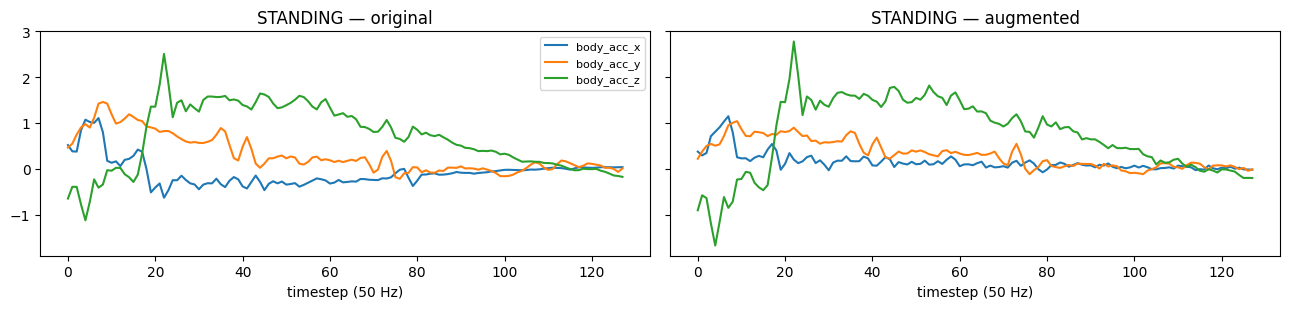

In [10]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2), sharey=True)
i = 0
for ax, data, title in [(axes[0], Xseq["train"][i], "original"), (axes[1], Xseq_train_aug[len(Xseq["train"]) + i] if AUG_COPIES else Xseq["train"][i], "augmented")]:
    for c, name in enumerate(SIGNALS[:3]): ax.plot(data[:, c], label=name)
    ax.set_title(f"{CLASSES[Y['train'][i]]} — {title}"); ax.set_xlabel("timestep (50 Hz)")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

## 9. Save processed data
Everything goes into one folder. Mount Google Drive first if you want it to survive the Colab session ending.

In [11]:
SAVE_TO_DRIVE = False
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    OUT_DIR = "/content/drive/MyDrive/har_processed"; os.makedirs(OUT_DIR, exist_ok=True)

np.savez_compressed(f"{OUT_DIR}/tabular.npz",
    X_train=Xtab_train_aug, y_train=ytab_train_aug,
    X_val=Xtab["val"], y_val=Y["val"], X_test=Xtab["test"], y_test=Y["test"])

np.savez_compressed(f"{OUT_DIR}/sequence.npz",
    X_train=Xseq_train_aug, y_train=y_train_aug,
    X_train_noaug=Xseq["train"], y_train_noaug=Y["train"],
    X_val=Xseq["val"], y_val=Y["val"], X_test=Xseq["test"], y_test=Y["test"])

import joblib
joblib.dump({"tab_scaler": tab_scaler, "label_encoder": le,
             "seq_mean": ch_mean, "seq_std": ch_std,
             "feature_names": X_df.columns.tolist(), "signals": SIGNALS}, f"{OUT_DIR}/preprocessors.joblib")

meta = {"classes": CLASSES, "class_weight": {int(k): float(v) for k, v in CLASS_WEIGHT.items()},
        "split_mode": SPLIT_MODE, "aug_copies": AUG_COPIES, "aug_ops": list(AUG_OPS),
        "subjects": {s: sorted(np.unique(subj[ix]).tolist()) for s, ix in
                     [("train", train_idx), ("val", val_idx), ("test", test_idx)]},
        "cleaning": report}
json.dump(meta, open(f"{OUT_DIR}/meta.json", "w"), indent=2)
print(os.listdir(OUT_DIR))

['sequence.npz', 'tabular.npz', 'meta.json', 'preprocessors.joblib']


## 10. Loading for each model family
Copy the block you need into your training notebook.

In [12]:
# ---- Classical ML (sklearn / XGBoost / LightGBM) ----
d = np.load(f"{OUT_DIR}/tabular.npz")
Xtr, ytr, Xva, yva, Xte, yte = (d[k] for k in ["X_train","y_train","X_val","y_val","X_test","y_test"])

# ---- Keras / TensorFlow: input (128, 9) ----
s = np.load(f"{OUT_DIR}/sequence.npz")
# model.fit(s["X_train"], s["y_train"], validation_data=(s["X_val"], s["y_val"]),
#           class_weight=CLASS_WEIGHT)   # use loss="sparse_categorical_crossentropy"

# ---- PyTorch: Conv1d wants (N, channels, time) -> transpose ----
# import torch
# from torch.utils.data import TensorDataset, DataLoader
# Xt = torch.tensor(s["X_train"]).permute(0, 2, 1)      # (N, 9, 128); keep (N,128,9) for LSTM(batch_first=True)
# train_dl = DataLoader(TensorDataset(Xt, torch.tensor(s["y_train"]).long()), batch_size=64, shuffle=True)

## 11. Quick baseline (proves the pipeline end to end)
A logistic regression on the tabular view should land around 93–96% test accuracy. If it's far lower, something upstream is off.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr)
for name, Xs, ys in [("val", Xva, yva), ("test", Xte, yte)]:
    p = clf.predict(Xs)
    print(f"{name}: acc={accuracy_score(ys, p):.4f}  macro-F1={f1_score(ys, p, average='macro'):.4f}")
print(classification_report(yte, clf.predict(Xte), target_names=CLASSES))

val: acc=0.9572  macro-F1=0.9533
test: acc=0.9511  macro-F1=0.9505
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.96      0.87      0.91       491
          STANDING       0.88      0.96      0.92       532
           WALKING       0.95      0.99      0.97       496
WALKING_DOWNSTAIRS       0.98      0.91      0.95       420
  WALKING_UPSTAIRS       0.95      0.96      0.96       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947

